# Actuator dynamics: powertrain step response

Wheels raised, so this is the closed-loop response (setpoint -> actual speed with
the PID inside), which is exactly what the NMPC will command in Phase 9. The time
constant depends on the PID gains: if Kp/Ki change, this identification is stale.

Four speed steps, commanded 0.3, 0.6, 1.0, 1.32 m/s with the stock radius. Only
the wheel speed in rad/s is physical, so steps are labelled on slicks
(0.0299 m) below. /drive is not in the bag (no ackermann_msgs on the Pi at the
time), so steps are found from the wheel speed and dead time is not observable.

In [1]:
import sys
sys.path.append('../scripts')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import bagtools as bt

R_WHEEL = 0.0299                        # slick
TAU_F = -0.01 / np.log(1 - 0.2)         # firmware EMA on wheel speed, alpha 0.2 at 100 Hz

dfs = bt.load('../data/actuator_steps_parquet')
dfs = bt.zero_time(dfs)
js = dfs['joint_states']
js['w'] = (js['wl'] + js['wr']) / 2.0
print(f"EMA time constant {TAU_F * 1000:.1f} ms")

EMA time constant 44.8 ms


/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Detect the steps

A step starts at the last sample at rest before the wheel speed rises. Starting
at a threshold crossing instead (2 rad/s) throws away the first part of the rise
and makes tau come out too short. The fit window stops 1.7 s after the start,
before the step comes back down. Plateau: 90th percentile of the moving samples.

In [2]:
w = js['w'].values
t = js['t'].values

steps = []
for i in np.flatnonzero((w[1:] > 2.0) & (w[:-1] <= 2.0)) + 1:
    j = i
    while w[j - 1] > 0.3:
        j -= 1
    seg = bt.window(js, t[j - 1], t[j - 1] + 1.7)
    steps.append((t[j - 1], np.percentile(seg['w'][seg['w'] > 2.0], 90)))

for t0, plateau in steps:
    print(f"  t = {t0:6.2f} s   plateau {plateau:5.1f} rad/s   ({plateau * R_WHEEL:.2f} m/s on slicks)")

  t =  22.37 s   plateau   8.8 rad/s   (0.26 m/s on slicks)
  t =  37.91 s   plateau  17.6 rad/s   (0.53 m/s on slicks)
  t =  47.01 s   plateau  29.3 rad/s   (0.88 m/s on slicks)
  t =  52.47 s   plateau  38.8 rad/s   (1.16 m/s on slicks)


## Fit each step

The wheel speed in `/joint_states` is the EMA-filtered one, so the measurement
lags the wheel. Two models, time from the start of the step:

$$\text{first order:}\quad \omega(t) = \omega_\infty\left(1 - e^{-t/\tau}\right)$$

$$\text{actuator + EMA:}\quad \omega(t) = \omega_\infty\left(1 - \frac{\tau e^{-t/\tau} - \tau_f e^{-t/\tau_f}}{\tau - \tau_f}\right)$$

The first is what the encoder reading does, the second separates the actuator
$\tau$ from the known filter $\tau_f$.

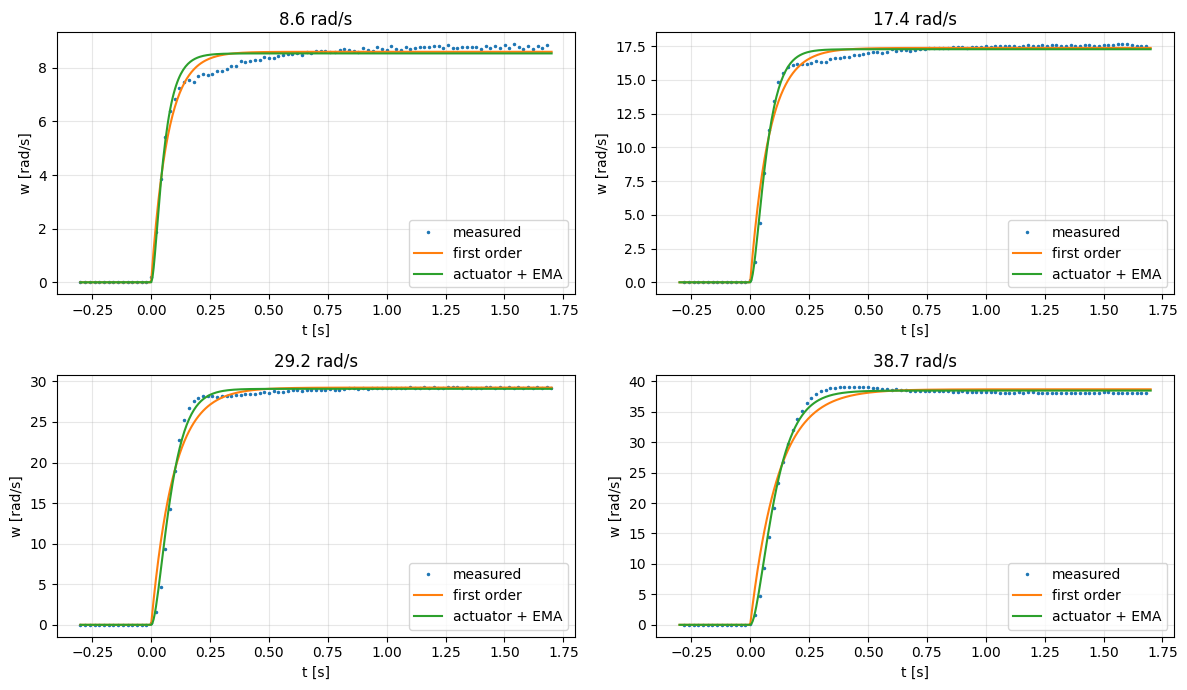

In [3]:
def first_order(t, w_inf, tau):
    return np.where(t > 0, w_inf * (1 - np.exp(-t / tau)), 0.0)


def with_filter(t, w_inf, tau):
    y = w_inf * (1 - (tau * np.exp(-t / tau) - TAU_F * np.exp(-t / TAU_F)) / (tau - TAU_F))
    return np.where(t > 0, y, 0.0)


results = []
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (t0, plateau) in zip(axes.flat, steps):
    seg = bt.window(js, t0 - 0.3, t0 + 1.7)
    tr, y = seg['t'].values - t0, seg['w'].values
    p1, _ = curve_fit(first_order, tr, y, p0=[plateau, 0.1], bounds=([0, 0.005], [100, 2]))
    p2, _ = curve_fit(with_filter, tr, y, p0=[plateau, 0.05], bounds=([0, 0.005], [100, 2]))
    results.append({'w_inf [rad/s]': p1[0], 'v slick [m/s]': p1[0] * R_WHEEL,
                    'tau measured [ms]': 1000 * p1[1], 'tau actuator [ms]': 1000 * p2[1]})

    tt = np.linspace(-0.3, 1.7, 400)
    ax.plot(tr, y, '.', ms=3, label='measured')
    ax.plot(tt, first_order(tt, *p1), lw=1.5, label='first order')
    ax.plot(tt, with_filter(tt, *p2), lw=1.5, label='actuator + EMA')
    ax.set_title(f'{p1[0]:.1f} rad/s')
    ax.set_xlabel('t [s]')
    ax.set_ylabel('w [rad/s]')
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

## Summary: is the actuator linear?

In [4]:
res = pd.DataFrame(results).round(2)
res

,w_inf [rad/s],v slick [m/s],tau measured [ms],tau actuator [ms]
0,8.60,0.26,70.46,14.85
1,17.36,0.52,81.27,30.23
2,29.23,0.87,95.01,45.32
3,38.68,1.16,118.34,69.90


Tau grows with amplitude: 70 -> 118 ms measured, 15 -> 70 ms for the actuator
alone. The top step runs into the motor free speed with ~4% of stall torque
left (step 5.1), so the last point is saturation, not a linear time constant.
Neither model has the slow PI tail, clearest on the smallest step. On the larger
steps the filter model follows the rise better, and the top step overshoots and
settles lower, again saturation.

## For vehicle_params.yaml

Actuator tau from the low/mid steps, **~15-45 ms up to 0.9 m/s**, plus the known
45 ms EMA on the measured wheel speed. A predictor that takes the encoder speed
as its state should use the measured value, ~70-95 ms. Closed-loop values, tied
to Kp = 1500, Ki = 6000.

The servo response is not identified here: /steering_angle publishes the
commanded angle, not the physical one. If servo dynamics matter in Phase 9,
refine with high-speed video.